In [1]:
import sys
#%cd variational_inference_for_longitudinal_data/
sys.path.append('../..')
sys.path.append('../../lib/src/')
import torch
from torch import nn
import torch.nn.functional as F
import os
from matplotlib import pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np
import logging




from diffusion.stable_diffusion.latent_diffusion import MyLatentDiffusion, LitLDM
from diffusion.stable_diffusion.model.unet import UNetModel
from diffusion.stable_diffusion.sampler.ddim import DDIMSampler

from lib.src.pythae.models import VAE
from lib.src.pythae.models.vae import VAEConfig
from lib.src.pythae.models import LLDM_IAF, LVAE_IAF_Config, LVAE_IAF
from lib.src.pythae.trainers import BaseTrainerConfig, BaseTrainer
from lib.scripts.utils import Encoder_Chairs,Decoder_Chairs
from lib.scripts.utils import My_MaskedDataset, make_batched_masks
from lib.src.pythae.trainers.training_callbacks import WandbCallback

from geometric_perspective_on_vaes.sampling import hmc_sampling


def load_config_unet(config):
    return UNetModel(
        in_channels=config['in_channels'],
        out_channels=config['out_channels'],
        channels=config['channels'],
        n_res_blocks=config['n_res_blocks'],
        attention_levels=config['attention_levels'],
        channel_multipliers=config['channel_multipliers'],
        n_heads=config['n_heads'],
    )


def plot_sequence(X):

    if len(X.shape) == 4:
        X = X.unsqueeze(0)

    X = X.cpu().detach().numpy()
    num_seq = X.shape[0]
    num_obs = X.shape[1]

    logger = logging.getLogger()
    old_level = logger.level
    logger.setLevel(100)
    plt.figure(figsize=(num_obs, num_seq))
    for i in range(num_seq):
        for j in range(num_obs):
            plt.subplot(num_seq, num_obs, i*num_obs+j+1)
            plt.imshow(X[i, j].transpose(1, 2, 0))
            plt.axis('off')

    plt.show()
    logger.setLevel(old_level)


%reload_ext autoreload
%autoreload 2

!nvidia-smi

Mon Aug 19 15:04:42 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.107.02             Driver Version: 550.107.02     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A2000 12GB          Off |   00000000:01:00.0 Off |                  Off |
| 30%   54C    P8             11W /   70W |     119MiB /  12282MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
PATH_DATA = 'my_data/sprites/Sprites_train.pt'


train_data = torch.load(os.path.join(PATH_DATA))[:-1000, :-1, :, :, :]
eval_data = torch.load(os.path.join(PATH_DATA), map_location="cpu")[-1000:, :-1, :, :, :]
test_data = torch.load(os.path.join('my_data/sprites/Sprites_test.pt'), map_location="cpu")[:, :-1, :, :, :]

print(train_data.shape)
train_data = train_data.permute(0, 1, 4, 2, 3)
eval_data = eval_data.permute(0, 1, 4, 2, 3)
test_data = test_data.permute(0, 1, 4, 2, 3)
print(train_data.shape)

train_seq_mask = torch.ones(train_data.shape[:2], requires_grad=False).type(torch.bool)
eval_seq_mask = torch.ones(eval_data.shape[:2], requires_grad=False).type(torch.bool)
#test_seq_mask = torch.ones(test_data.shape[:2], requires_grad=False).type(torch.bool)
train_pix_mask = torch.ones_like(train_data, requires_grad=False).type(torch.bool)
eval_pix_mask = torch.ones_like(eval_data, requires_grad=False).type(torch.bool)
#test_pix_mask = torch.ones_like(test_data, requires_grad=False).type(torch.bool)

train_dataset = My_MaskedDataset(train_data, train_seq_mask, train_pix_mask)
eval_dataset = My_MaskedDataset(eval_data, eval_seq_mask, eval_pix_mask)
#test_dataset = My_MaskedDataset(test_data, test_seq_mask, test_pix_mask)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=200, shuffle=True)
val_loader = torch.utils.data.DataLoader(eval_data, batch_size=200, shuffle=True)

torch.Size([8000, 7, 64, 64, 3])
torch.Size([8000, 7, 3, 64, 64])


In [3]:
# encoder = Encoder_Chairs(config)
# decoder = Decoder_Chairs(config)
# vae = LVAE_IAF(config, encoder, decoder)


PATH_VAE_FOLDER = 'pre-trained_vae/VAE_training_2024-06-16_15-12-03/final_model'
PATH_DIFFUSION_CKPT = 'ldm_retrain/lightning_logs/version_3/checkpoints/epoch=99-step=3200.ckpt'


# Avec prior 'allongée' mais pas décalée
# PATH_VAE_FOLDER = 'pre-trained_vae/VAE_training_2024-06-27_11-46-10/final_model'
# PATH_DIFFUSION_CKPT = 'ldm/lightning_logs/version_7/checkpoints/epoch=49-step=1600.ckpt'


# Prior décalée
# PATH_VAE_FOLDER = 'pre-trained_vae/VAE_training_2024-07-01_16-05-18/final_model'
# PATH_DIFFUSION_CKPT = 'ldm/lightning_logs/version_15/checkpoints/epoch=49-step=1600.ckpt'

device = 'cuda'
vae = VAE.load_from_folder(PATH_VAE_FOLDER).to(device)
vae.eval()
#_, _, _ = vae.retrieveG(train_data, verbose = True, T_multiplier=5, device = device, addStdNorm=True)


# in_channels = 3
# out_channels = 3
# channels = 32
# n_res_blocks = 2
# attention_levels = [2]
# channel_multipliers = (1, 2, 4)
# n_heads = 16


in_channels = 3
out_channels = 3
channels = 64
n_res_blocks = 4
attention_levels = [0]
channel_multipliers = [1]
n_heads = 4

unet_config = {
    'in_channels': in_channels,
    'out_channels': out_channels,
    'channels': channels,
    'n_res_blocks': n_res_blocks,
    'attention_levels': attention_levels,
    'channel_multipliers': channel_multipliers,
    'n_heads': n_heads,
}

unet = load_config_unet(unet_config)

latent_scaling_factor = 1
n_steps = 1000

#Pas oublier de modif
linear_start =  0.00085
linear_end = 0.012

input_dim = (3, 64, 64)
f = 32 #subsampling factor
latent_dim = 3* (64 // f) * (64 // f)
print('Latent dim:', latent_dim)


latent_diffusion = MyLatentDiffusion(unet, latent_scaling_factor, latent_dim, n_steps, linear_start, linear_end)
print('Number of parameters in the diffusion model: ', sum(p.numel() for p in latent_diffusion.parameters() if p.requires_grad))

model = LitLDM.load_from_checkpoint(PATH_DIFFUSION_CKPT, ldm = latent_diffusion, vae = vae, latent_dim = latent_dim, lr = 6e-4).to(device)
diffusion = model.ldm

Latent dim: 12
Number of parameters in the diffusion model:  2223043


In [4]:
model_config = LVAE_IAF_Config(
    input_dim=(3, 64, 64),
    n_obs_per_ind=train_data.shape[1], #8 for Sprites, 7 as we remove last obs
    latent_dim=latent_dim,
    beta=0.2,
    n_hidden_in_made=2,
    n_made_blocks=4,
    warmup=0,
    context_dim=None,
    prior='standard',
    posterior='gaussian',
    linear_scheduling_steps=10,

)
training_config = BaseTrainerConfig(
        num_epochs=100,
        learning_rate=1e-4,
        batch_size=256,
        steps_saving=50,
        steps_predict=100,
        shuffle=True,
        output_dir='lldm'
    )


device = 'cuda'
encoder = Encoder_Chairs(model_config).to(device)
decoder = Decoder_Chairs(model_config).to(device)
ddim_sampler = DDIMSampler(diffusion, n_steps = train_data.shape[1]-1, ddim_eta = 1)

temperature = 1


#############
# lldm = LLDM_IAF(model_config=model_config, encoder=encoder, decoder=decoder, 
#                 pretrained_vae=vae, pretrained_ldm=diffusion, ddim_sampler=ddim_sampler,
#                 precomputed_zT_samples=zT_samples, GM = GM, verbose = True)

lldm = LLDM_IAF(model_config=model_config, encoder=encoder, decoder=decoder, 
                 pretrained_vae=vae, pretrained_ldm=diffusion, ddim_sampler=ddim_sampler,
                verbose = True, temp = temperature)

lvae = LVAE_IAF.load_from_folder('lldm/LVAE_IAF_training_2024-08-02_14-52-51/final_model').to(device)

Diffusion time steps  [997 831 665 499 333 167   1]
Running on  cuda:0
Freezing pre-trained VAE and pre-trained LDM...
Freezing done.
Number of trainable parameters: 1.1e+06
Number of total parameters: 4.4e+06


In [5]:
#lldm.load_state_dict(torch.load('lldm/LLDM_IAF_training_2024-07-02_14-46-51/final_model/model.pt')['model_state_dict'])
lldm.load_state_dict(torch.load('lldm/LLDM_IAF_training_2024-07-02_18-30-00/final_model/model.pt')['model_state_dict'])

<All keys matched successfully>

In [86]:
def extract_train_embeddings(model, train_data, batch_size = 256):
    train_embeddings = [] 
    #log_vars = []
    train_loader = torch.utils.data.DataLoader(train_data, batch_size=256, shuffle=False)
    for i, x in enumerate(train_loader):
        x = x.to('cuda')
        out = model.encoder(x)
        z = out.embedding.reshape(-1, model.n_obs, model.latent_dim)
        log_var = out.log_covariance
        train_embeddings.append(z.cpu().detach())
        #log_vars.append(log_var.cpu().detach())
    train_embeddings = torch.cat(train_embeddings, dim = 0)

    return train_embeddings


def plot_z_seqs(z_seq, train_embeddings):

    num_obs =  NUM_OBS =  train_embeddings.shape[1] 
    pca = PCA(n_components=2)
    n_samples = z_seq.shape[0]
    train_embeddings_pca = pca.fit_transform(train_embeddings.reshape(-1, latent_dim).cpu().detach().numpy()).reshape(-1, num_obs, 2)

    displayed_indexes = range(num_obs)  #range(num_obs)

    all_sequences = z_seq
    all_sequences_pca = pca.transform(all_sequences.reshape(-1, latent_dim).cpu().detach().numpy())
    all_sequences_pca = all_sequences_pca.reshape(n_samples, -1, 2)
    plt.figure(figsize=(NUM_OBS, n_samples))
    plt.scatter(all_sequences_pca[:, :, 0], all_sequences_pca[:, :, 1], s=20, color='purple', label='Samples')
    colors = plt.get_cmap('tab10', num_obs)
    for i in displayed_indexes:
        plt.scatter(train_embeddings_pca[:, i, 0], train_embeddings_pca[:, i, 1], s=0.5, color=colors(i), label=f'Train obs. {i}')

    for i in range(n_samples):
        plt.plot(all_sequences_pca[i, :, 0], all_sequences_pca[i, :, 1], c = 'purple')


    plt.legend()
    plt.show()


## Testing reconstruction

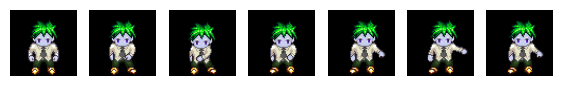

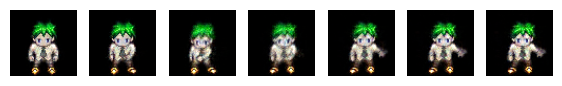

Reconstruction loss LLDM : 33.837745666503906


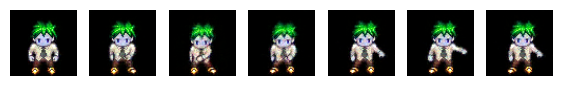

Reconstruction loss LVAE : 16.732484817504883


In [7]:
### TESTING RECONSTRUCTION ###
lldm, lvae = lldm.to('cuda'), lvae.to('cuda')
lldm, lvae = lldm.eval(), lvae.eval()

vi_index = 3

idx = torch.randint(0, len(train_dataset), (1,)).item()
x = train_dataset[idx]



z_seq, x_rec = lldm.reconstruct(x, vi_index = vi_index)
_, x_rec_lvae = lvae.reconstruct(x, vi_index = vi_index)

x = x.data.unsqueeze(0)
x = x.to(x_rec.device)
plot_sequence(x.data)
plot_sequence(x_rec)

recon_loss = (
                0.5 * (
                    F.mse_loss(
                        x_rec.reshape(x.shape[0]*lldm.n_obs, -1),
                        x.reshape(x.shape[0]*lldm.n_obs, -1),
                        reduction="none"
                    )).sum(dim=-1).reshape(x.shape[0], -1)
            ).mean(dim=-1).item()

print('Reconstruction loss LLDM :', recon_loss)

plot_sequence(x_rec_lvae)

recon_loss = (
                0.5 * (
                    F.mse_loss(
                        x_rec_lvae.reshape(x.shape[0]*lldm.n_obs, -1),
                        x.reshape(x.shape[0]*lldm.n_obs, -1),
                        reduction="none"
                    )).sum(dim=-1).reshape(x.shape[0], -1)
            ).mean(dim=-1).item()

print('Reconstruction loss LVAE :', recon_loss)





In [66]:
train_embeddings = extract_train_embeddings(lldm, train_data)
train_embeddings_lvae = extract_train_embeddings(lvae, train_data)

print(train_embeddings.shape)
print(train_embeddings_lvae.shape)

torch.Size([8000, 7, 12])
torch.Size([8000, 7, 12])


## Testing generation 
### (without freezing a given obs)

Running Kmedoids
Finding temperature
Best temperature found:  120.40079498291016
Building metric
Increasing T by  0.7
Sampling 5 points on the 4th/rd manifold...
Batch 1/1
Propagating in the past...
Propagating in the future...
Decoding...


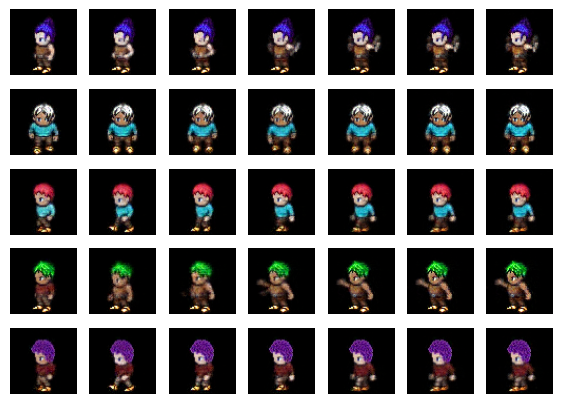

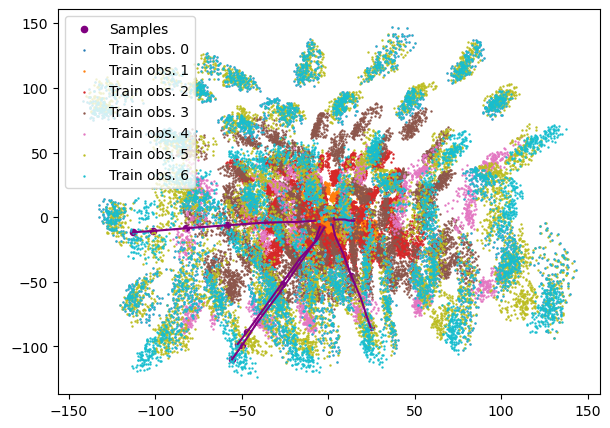

In [68]:
lldm.temperature = 1
recon_x, z_seq = lldm.generate(train_data, num_gen_seq=5, vi_index =4, T_multiplier = 0.7)
plot_sequence(recon_x)
plot_z_seqs(z_seq, train_embeddings)

## Testing generation 
### (with freezing a given obs)

Running Kmedoids


/users/eleves-a/2020/meilame.tayebjee/miniconda3/lib/python3.12/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 112 is empty! self.labels_[self.medoid_indices_[112]] may not be labeled with its corresponding cluster (112).
  warnings.warn(
/users/eleves-a/2020/meilame.tayebjee/miniconda3/lib/python3.12/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 177 is empty! self.labels_[self.medoid_indices_[177]] may not be labeled with its corresponding cluster (177).
  warnings.warn(
/users/eleves-a/2020/meilame.tayebjee/miniconda3/lib/python3.12/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 188 is empty! self.labels_[self.medoid_indices_[188]] may not be labeled with its corresponding cluster (188).
  warnings.warn(
/users/eleves-a/2020/meilame.tayebjee/miniconda3/lib/python3.12/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 194 is empty! self.labels_[self.medoid_indices_[194]] ma

Finding temperature
Best temperature found:  2.5649054050445557
Building metric
Increasing T by  0.5
Freezing the 0th/rd obs...
Sampling 1 point on the 0th/rd manifold...


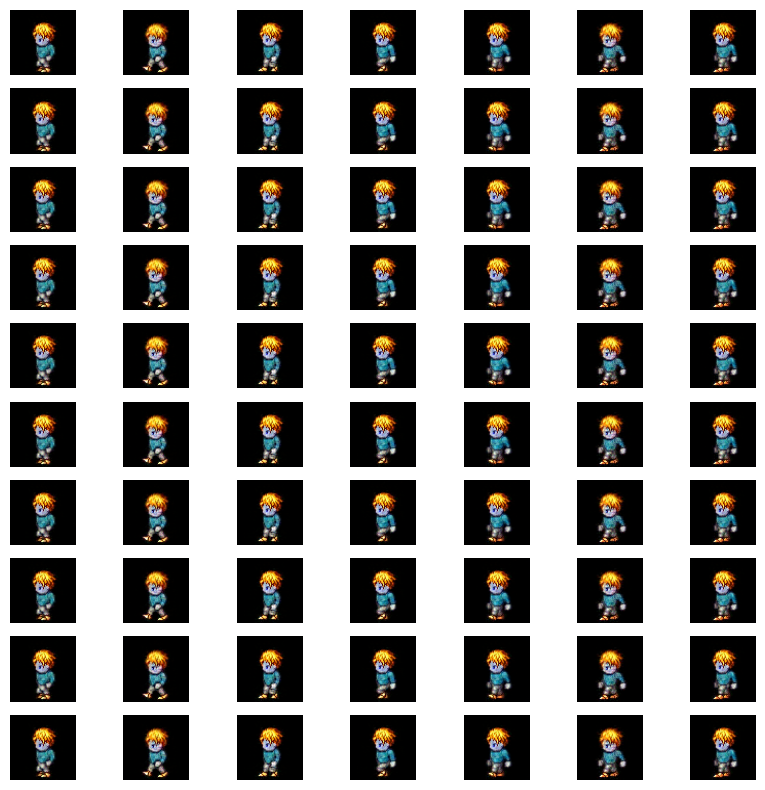

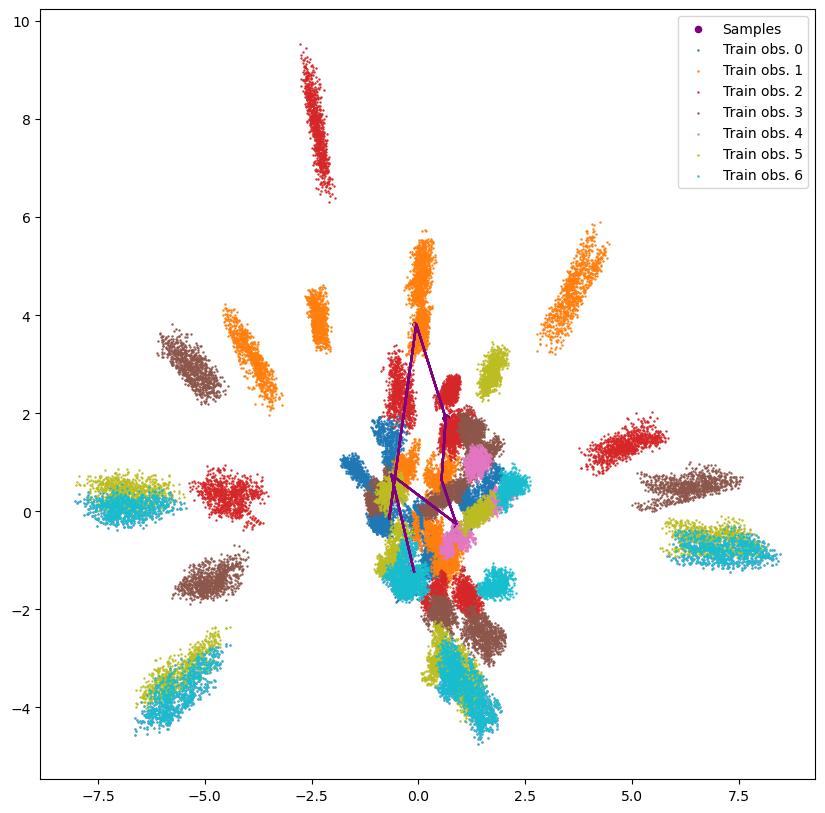

In [28]:
recon_x_lvae, z_seq_lvae = lvae.generate(train_data, num_gen_seq=10, vi_index = 0, freeze = True)
plot_sequence(recon_x_lvae)
plot_z_seqs(z_seq_lvae, train_embeddings_lvae)

Running Kmedoids
Finding temperature
Best temperature found:  8.50917911529541
Building metric
Increasing T by  1
Freezing the 0th/rd obs...
Sampling 1 point on the 0th/rd manifold...
Batch 1/1
Propagating in the future...
Decoding...


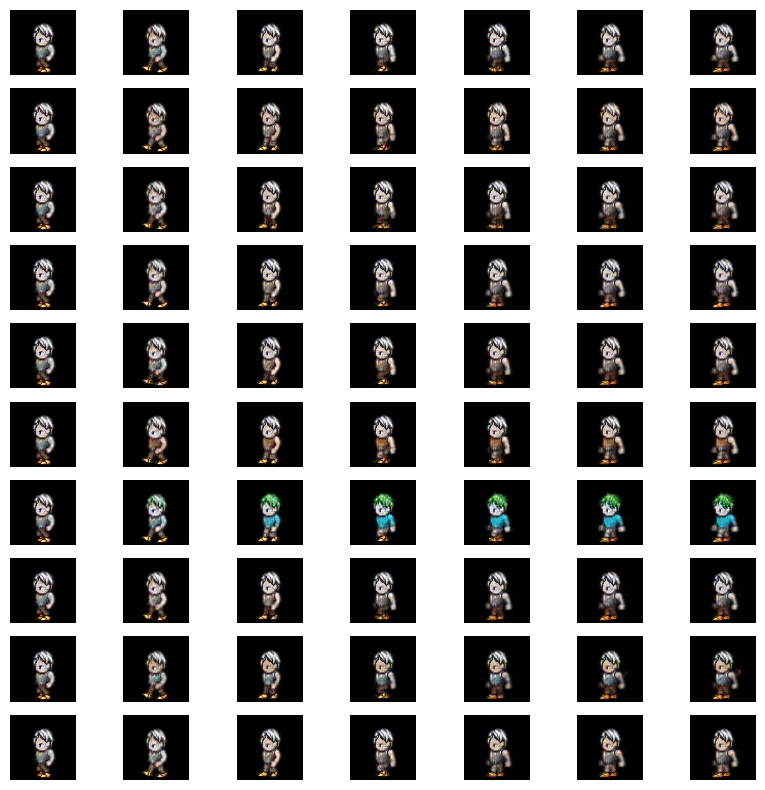

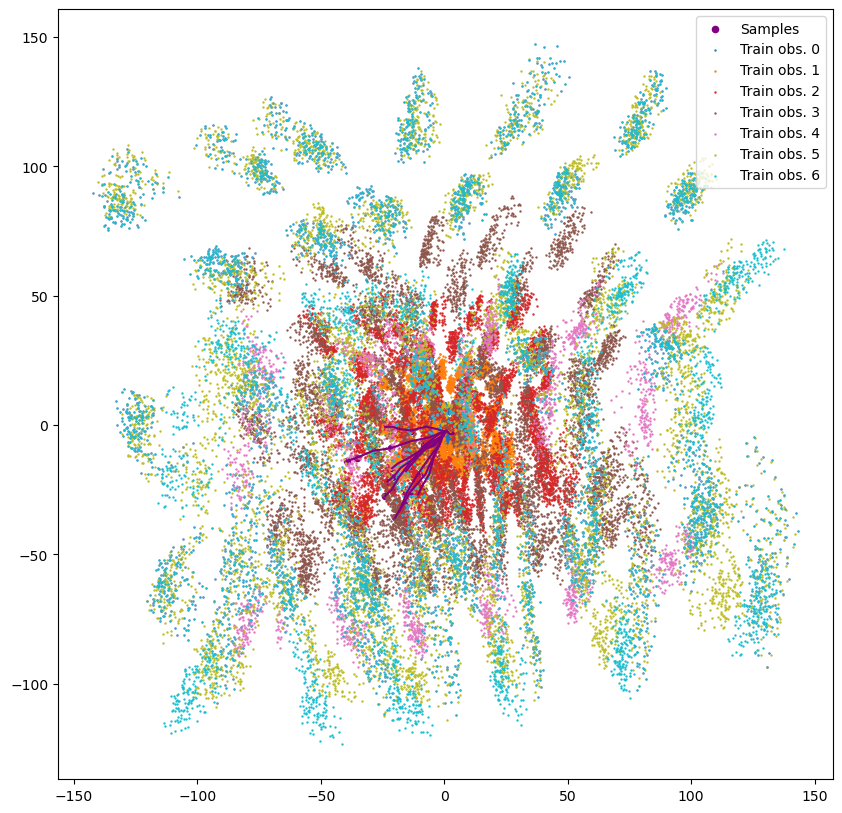

In [33]:
lldm.temperature = 2
recon_x, z_seq = lldm.generate(train_data, num_gen_seq=10, vi_index =0, T_multiplier = 1, freeze=True)
plot_sequence(recon_x)
plot_z_seqs(z_seq, train_embeddings)

## Exploring overfitting

/tmp/ipykernel_4461/3542419053.py:5: UserWarning: Using a target size (torch.Size([7, 3, 64, 64])) that is different to the input size (torch.Size([1, 7, 3, 64, 64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  dist = F.mse_loss(x, gen)


Distance tensor(0.0045)
Generated...


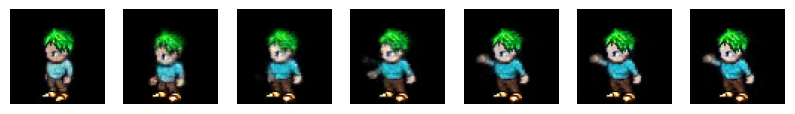

Closest training sample...


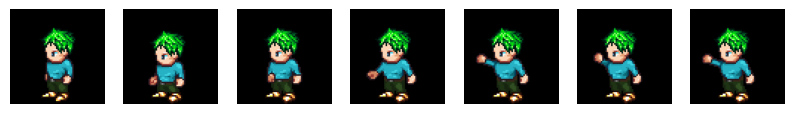

Distance tensor(0.0046)
Generated...


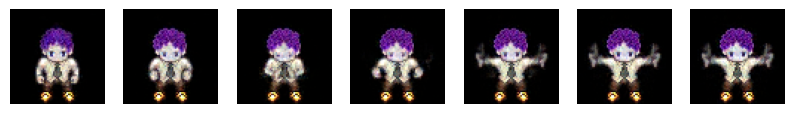

Closest training sample...


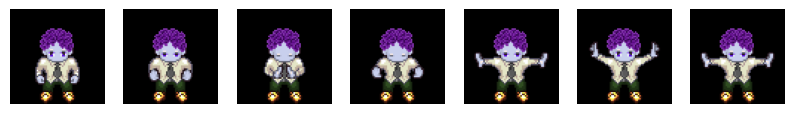

Distance tensor(0.0038)
Generated...


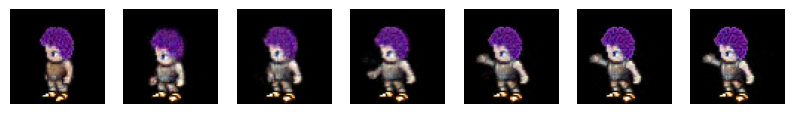

Closest training sample...


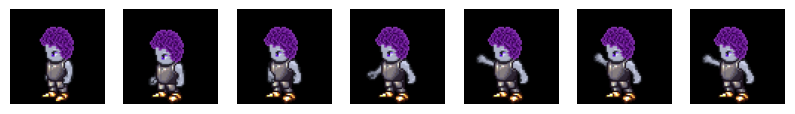

Distance tensor(0.0036)
Generated...


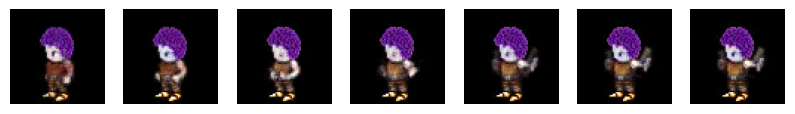

Closest training sample...


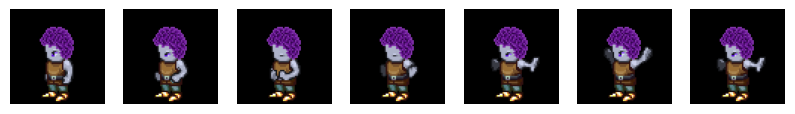

Distance tensor(0.0028)
Generated...


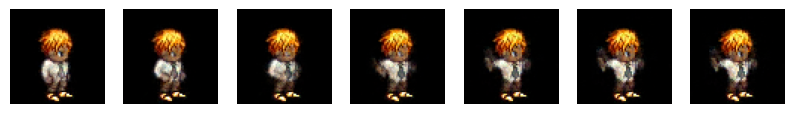

Closest training sample...


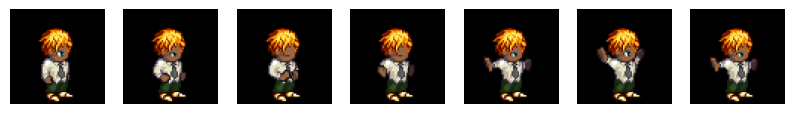

Distance tensor(0.0036)
Generated...


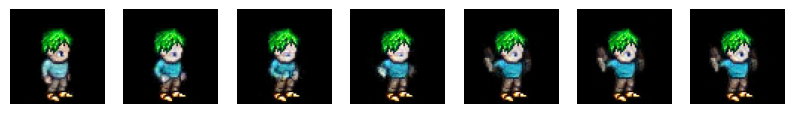

Closest training sample...


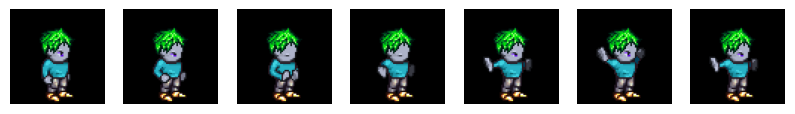

Distance tensor(0.0038)
Generated...


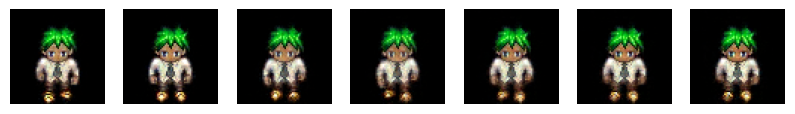

Closest training sample...


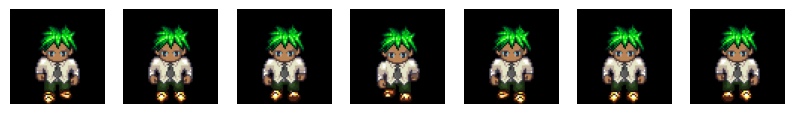

Distance tensor(0.0021)
Generated...


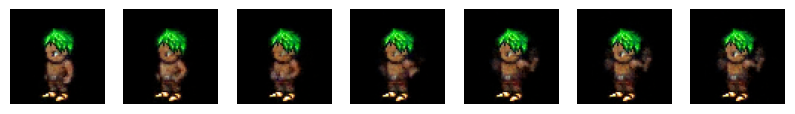

Closest training sample...


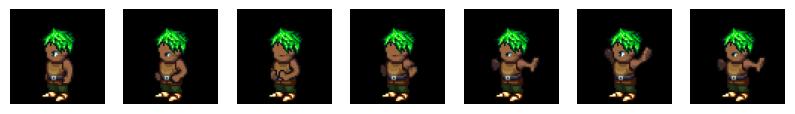

Distance tensor(0.0031)
Generated...


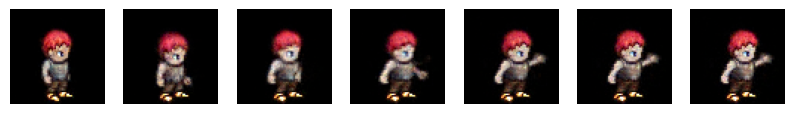

Closest training sample...


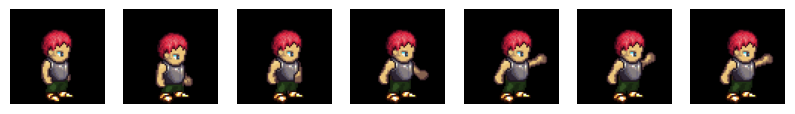

Distance tensor(0.0040)
Generated...


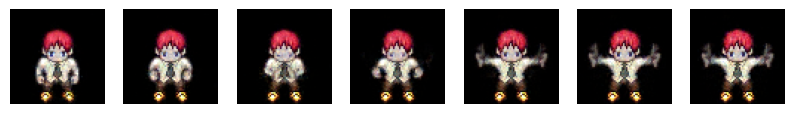

Closest training sample...


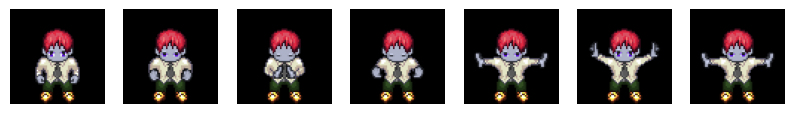

In [33]:
for l in range(recon_x.shape[0]):
    gen = recon_x[l]
    min_dist = torch.inf
    for i, x in enumerate(train_loader):
        dist = F.mse_loss(x, gen)
        if dist < min_dist:
            min_dist = dist
            idx = i
            x_min = x

    print("Distance", min_dist)
    print('Generated...')
    plot_sequence(gen)
    print('Closest training sample...')
    plot_sequence(x_min)

## FID and IS

In [6]:
recon_x, z_seq = lldm.generate(train_data, num_gen_seq=test_data.shape[0], vi_index =3 , T_multiplier = 1, verbose = False, batch_size = 128)
recon_x_lvae, z_seq_lvae = lvae.generate(train_data, num_gen_seq=test_data.shape[0], vi_index = 0, T_multiplier = 1, verbose = True)
print(recon_x.shape)
print(recon_x_lvae.shape)
print(test_data.shape)

Running Kmedoids


/users/eleves-a/2020/meilame.tayebjee/miniconda3/lib/python3.12/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 112 is empty! self.labels_[self.medoid_indices_[112]] may not be labeled with its corresponding cluster (112).
  warnings.warn(
/users/eleves-a/2020/meilame.tayebjee/miniconda3/lib/python3.12/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 177 is empty! self.labels_[self.medoid_indices_[177]] may not be labeled with its corresponding cluster (177).
  warnings.warn(
/users/eleves-a/2020/meilame.tayebjee/miniconda3/lib/python3.12/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 188 is empty! self.labels_[self.medoid_indices_[188]] may not be labeled with its corresponding cluster (188).
  warnings.warn(
/users/eleves-a/2020/meilame.tayebjee/miniconda3/lib/python3.12/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 194 is empty! self.labels_[self.medoid_indices_[194]] ma

Finding temperature
Best temperature found:  2.5649054050445557
Building metric
Increasing T by  1
Sampling 2664 points on the 0th/rd manifold...
Remainder batch size...: size 104
torch.Size([2664, 7, 3, 64, 64])
torch.Size([2664, 7, 3, 64, 64])
torch.Size([2664, 7, 3, 64, 64])


In [15]:
from torcheval.metrics import FrechetInceptionDistance

def compute_fid_with_torcheval(real_images, generated_images, batch_size=256, device='cuda'):
    # Initialize FID metric
    fid_metric = FrechetInceptionDistance().to(device)
    
    def process_in_batches(images, real):
        for i in range(0, len(images), batch_size):
            batch = images[i:i+batch_size].to(device)
            fid_metric.update(batch, is_real=real)
            # Clear the batch from memory
            del batch
            torch.cuda.empty_cache()
    
    # Process real images in batches
    process_in_batches(real_images, real=True)
    
    # Process generated images in batches
    process_in_batches(generated_images, real=False)
    
    # Compute the FID score
    fid_score = fid_metric.compute()
    return fid_score

# Example usage:
real_images = test_data.reshape(-1, 3, 64, 64).clamp(0, 1)
generated_images = recon_x.reshape(-1, 3, 64, 64).clamp(0, 1)
generated_images_lvae = recon_x_lvae.reshape(-1, 3, 64, 64).clamp(0, 1)

fid_score = compute_fid_with_torcheval(real_images, generated_images)
print('FID score LLDM:', fid_score)
fid_score_lvae = compute_fid_with_torcheval(real_images, generated_images_lvae)
print('FID score LVAE:', fid_score_lvae)


FID score LLDM: tensor(35.6827, device='cuda:0')
FID score LVAE: tensor(52.5099, device='cuda:0')


In [7]:
import torch
import torch.nn.functional as F
from torchvision.models import inception_v3
from scipy.stats import entropy
import numpy as np

# Load pre-trained InceptionV3 model
inception_model = inception_v3(pretrained=True, transform_input=True)
inception_model.eval()

def get_inception_score(images, num_splits=10, batch_size=32):
    num_images = images.size(0)
    preds = []

    # Process in batches
    with torch.no_grad():
        for i in range(0, num_images, batch_size):
            batch = images[i:i + batch_size]
            batch = F.interpolate(batch, size=(299, 299), mode='bilinear', align_corners=False)
            pred = inception_model(batch)
            preds.append(pred)

    preds = torch.cat(preds, dim=0).cpu().numpy()

    # Calculate the conditional probability
    p_yx = F.softmax(torch.tensor(preds), dim=1).numpy()
    
    # Calculate the marginal probability
    p_y = np.expand_dims(np.mean(p_yx, axis=0), axis=0)
    
    # Calculate the KL divergence for each image
    kl_div = p_yx * (np.log(p_yx + 1e-10) - np.log(p_y + 1e-10))
    kl_div = np.sum(kl_div, axis=1)
    
    # Average the KL divergence over all images
    score = np.mean(np.exp(kl_div))
    
    return score



/users/eleves-a/2020/meilame.tayebjee/miniconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/users/eleves-a/2020/meilame.tayebjee/miniconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [8]:
real_images = test_data.reshape(-1, 3, 64, 64).clamp(0, 1)
generated_images = recon_x.reshape(-1, 3, 64, 64).clamp(0, 1)
generated_images_lvae = recon_x_lvae.reshape(-1, 3, 64, 64).clamp(0, 1)


images = generated_images  # Your generated images as a PyTorch tensor of shape (N, 3, H, W)
score = get_inception_score(images)
print(f"Inception Score LLDM : {score}")

images = generated_images_lvae  # Your generated images as a PyTorch tensor of shape (N, 3, H, W)
score = get_inception_score(images)
print(f"Inception Score LVAE: {score}")


Inception Score LLDM : 2.49141263961792
Inception Score LVAE: 2.4336893558502197


In [1]:
pip install frechet_video_distance

ERROR: Could not find a version that satisfies the requirement frechet_video_distance (from versions: none)
ERROR: No matching distribution found for frechet_video_distance

[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## NLL

In [40]:
test_nll = []
batch_size=20
n_runs=1
n_samples = batch_size
lldm.device = 'cuda'
for _ in range(n_runs):
    test_nll.append(lldm.get_nll(data=test_data, vi_index = 3, n_samples=n_samples, batch_size=batch_size))

test_nll

  0%|          | 0/2664 [00:00<?, ?it/s]

  0%|          | 4/2664 [00:00<02:58, 14.92it/s]

Current nll at 0: -11311.315360019233


  4%|▍         | 104/2664 [00:06<02:44, 15.61it/s]

Current nll at 100: -11315.021117199056


...

Current nll at 2500: -11315.800763572448


 98%|█████████▊| 2603/2664 [02:48<00:03, 15.59it/s]

Current nll at 2600: -11315.777597006736


100%|██████████| 2664/2664 [02:52<00:00, 15.47it/s]


[-11315.780250096677]

## Future prediction

torch.Size([1, 10, 3, 3, 64, 64])


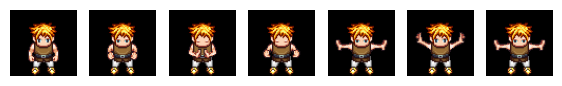

-------------------


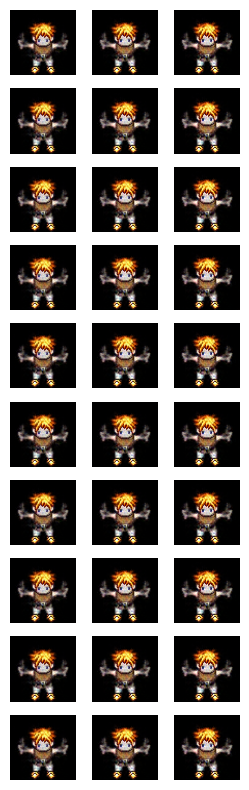

tensor([[96.5706, 96.5381, 96.6053, 96.9084, 97.2682, 96.5901, 97.0635, 97.7344,
         96.6389, 97.6434]])


/users/eleves-a/2020/meilame.tayebjee/miniconda3/lib/python3.12/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([1, 10, 3, 12288])) that is different to the input size (torch.Size([1, 1, 3, 12288])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [61]:
x = test_data[1027]
lldm.temperature = 1
index = 3
num_gen_seq = 10
neg_pos = index + 1 - lldm.n_obs
length_seq = lldm.n_obs - index - 1


full_x = lldm.predict(x, vi_index = index, num_gen_seq= num_gen_seq )

print(full_x.shape)
plot_sequence(x)
print("-------------------")
plot_sequence(full_x.squeeze(0))


pred = full_x.reshape(1, num_gen_seq, length_seq, -1).cpu().clamp(0,1)
orig = x.unsqueeze(0)[:, neg_pos:].reshape(1, 1, length_seq, -1).clamp(0,1)

mse = nn.MSELoss(reduction = 'none')(orig, pred).cpu().detach()
mse = mse.sum(dim = -1) #Sum over all pixels
mse = mse.mean(dim = -1) #Mean over all time steps
print(mse)


# for k in range(x.shape[0]):
#     plot_sequence(x[k])
#     plot_sequence(full_x[k])

    #orig = x[k].unsqueeze(0).cuda().squeeze(0)




    # for l in range(num_gen_seq):

    #     recon_x = full_x[k][l].unsqueeze(0).cuda().clamp(0, 1)
    #     plot_sequence(orig)
    #     plot_sequence(recon_x)
    #     gen = recon_x.clamp(0, 1).squeeze(0)
    #     recon_loss = (
    #     (
    #         F.mse_loss(
    #             recon_x.reshape(lldm.n_obs, -1),
    #             orig.reshape(lldm.n_obs, -1),
    #             reduction="none"
    #         )
    #     )).sum(dim=-1)
    #     print(recon_loss.shape)
    #     print('-------------------')
    #     print('MSE : ', recon_loss)
    #     print('-------------------')


In [69]:
from tqdm import tqdm


lldm.temperature = 0
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)
num_gen_seq = 10

loop_range = range(lldm.n_obs -1)


all_mses = []
for vi_index in loop_range:
    neg_pos = vi_index + 1 - lldm.n_obs
    length_seq = lldm.n_obs - vi_index - 1

    mses = []
    mc_stds = []
    for i, x in tqdm(enumerate(test_loader)):
        x = x.to('cuda')
        batch_size = x.shape[0]
        full_x = lldm.predict(x, vi_index = vi_index, num_gen_seq= num_gen_seq) #(B, num_gen, T, C, H, W)

        pred = full_x.reshape(batch_size, num_gen_seq, length_seq, -1)
        orig = x[:, neg_pos:].reshape(batch_size, 1, length_seq, -1)

        mse = nn.MSELoss(reduction = 'none')(orig, pred).cpu().detach()
        mse = mse.sum(dim = -1) #Sum over all pixels
        mse = mse.mean(dim = -1) #Mean over all time steps
        #mse = mse.mean(dim = -1) #Mean over all generated sequences

        #mse = mse.mean(dim = -2) #Mean over batch

        mses.append(mse)

    mses = torch.cat(mses).reshape(-1, num_gen_seq) # (len(test_data), num_gen_seq)
    all_mses.append(mses)

all_mses = torch.stack(all_mses, dim = 0) # (n_obs -1, len(test_data), num_gen_seq)

0it [00:00, ?it/s]/users/eleves-a/2020/meilame.tayebjee/miniconda3/lib/python3.12/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([64, 10, 6, 12288])) that is different to the input size (torch.Size([64, 1, 6, 12288])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
41it [00:11,  3.44it/s]/users/eleves-a/2020/meilame.tayebjee/miniconda3/lib/python3.12/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([40, 10, 6, 12288])) that is different to the input size (torch.Size([40, 1, 6, 12288])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
42it [00:12,  3.44it/s]
0it [00:00, ?it/s]/users/eleves-a/2020/meilame.tayebjee/miniconda3/lib/python3.12/site-packages/torch/nn/modules/loss.py:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


tensor([75.7417, 48.7604, 50.0150, 50.2099, 57.1483, 42.7068])


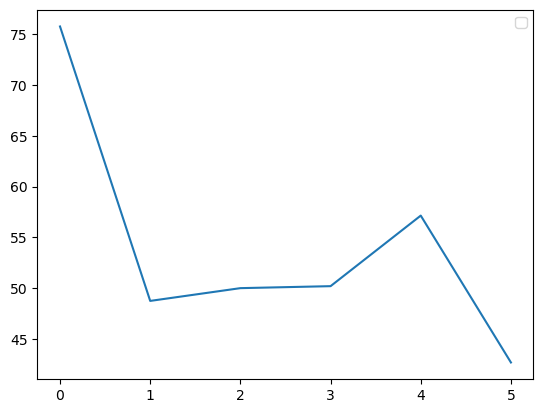

In [70]:
plot, _ = all_mses.mean(dim = 1).min(dim = - 1)
print(plot)
#std = all_mses.mean(dim = 1).std(dim = - 1)
plt.plot(plot)
#plt.fill_between(range(len(plot)), plot - std, plot + std, alpha=0.3)
plt.legend()
plt.show()

## Oversampling

Diffusion time steps  [999 889 778 667 556 445 334 223 112   1]
Running Kmedoids
Finding temperature
Best temperature found:  19.877626419067383
Building metric
Increasing T by  0.7
Sampling 5 points on the 1th/rd manifold...
Batch 1/1
Propagating in the past...
Propagating in the future...
Decoding...


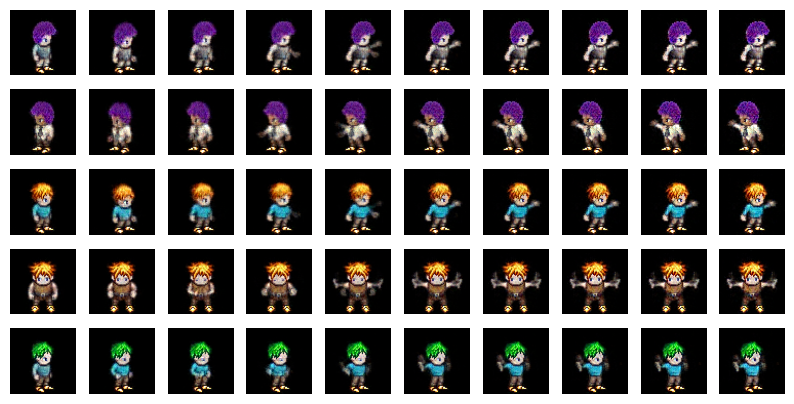

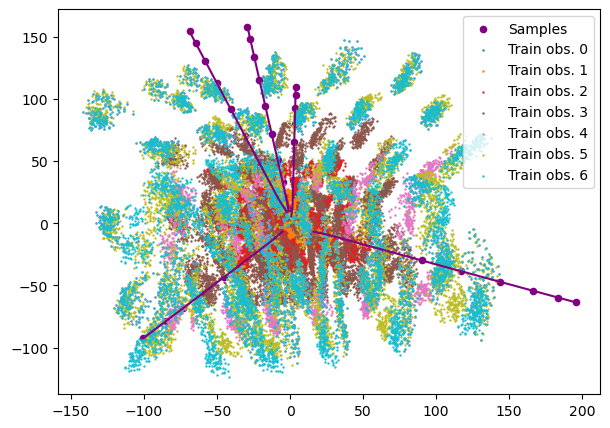

In [93]:
lldm.ddim_sampler = DDIMSampler(diffusion, n_steps = train_data.shape[1]+2, ddim_eta = 1)
lldm.n_obs = len(lldm.ddim_sampler.time_steps)
lldm.diff_t_steps = np.flip(lldm.ddim_sampler.time_steps)
print('Diffusion time steps ', lldm.diff_t_steps)

recon_x, z_seq = lldm.generate(train_data, num_gen_seq=5, vi_index =1, T_multiplier = 0.7)

plot_sequence(recon_x)
plot_z_seqs(z_seq, train_embeddings)